
# 1. Members feature engineering

## integrated_data 불러오기 및 기준일 설정

In [1]:
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지: 운영체제별 기본 한글 폰트 지정
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False   # 마이너스 기호가 네모로 깨지는 것 방지

TODAY = pd.to_datetime('2017-02-28')
df_all = pd.read_csv("../../data/processed/integrated_data.csv")


In [2]:
import easydict

args = easydict.EasyDict()
args.seed = 42
args.target = df_all['is_churn']

### 클래스 비율 확인

In [3]:
# 클래스 비율
df_all['is_churn'].value_counts()
df_all['is_churn'].value_counts() / df_all.shape[0]

# 전체 평균 이탈률: 모든 그래프의 비교 기준선
OVERALL = df_all["is_churn"].mean()  
print(f"전체 이탈률: {OVERALL:.2%}")

전체 이탈률: 8.95%


### member 관련 feature 엔지니어링

#### 멤버정보가 없는 멤버 관련 피쳐 생성

In [4]:
member_cols = ['city', 'bd', 'registered_via', 'registration_init_time']
df_all['has_member'] = (~df_all[member_cols].isna().all(axis=1)).astype(int)
#msno는있지만 다른 정보가 없는사람과 있는사람을 구분하는 컬럼
df_all['has_member'].value_counts()

has_member
1    88648
0    11352
Name: count, dtype: int64

#### registration_init_time

In [5]:
df_all['registration_init_time']= df_all['registration_init_time'].astype('Int64')

In [6]:
df_all['registration_init_time'] = pd.to_datetime(
    df_all['registration_init_time'].astype(str),
    format='%Y%m%d',     # 연4·월2·일2
    errors='coerce',     # 변환 불가 값은 에러 대신 NaN
)

reg = df_all['registration_init_time']
df_all['tenure_date'] = (TODAY- reg).dt.days  #가입 후 경과 일수


In [7]:

df_all['reg_year'] = reg.dt.year                            # 가입 연도




season_map = {3: '봄', 4: '봄', 5: '봄', 6: '여름', 7: '여름', 8: '여름',
              9: '가을', 10: '가을', 11: '가을', 12: '겨울', 1: '겨울', 2: '겨울'}
df_all['reg_season'] = reg.dt.month.map(season_map)         # 결측은 NaN → 10단계에서 채움

# 같은 날 가입 인원. groupby는 결측 키를 기본으로 빼서, members 없는 사람은 NaN
df_all['same_join_day'] = df_all.groupby('registration_init_time')['msno'].transform('count')

#### gender

In [8]:
# 성별: 결측을 '미입력'이라는 하나의 그룹으로 취급
df_all["gender_status"] = df_all["gender"].fillna("미입력")
df_all["gender_status"].unique()

array(['female', '미입력', 'male'], dtype=object)

#### bd

In [9]:
# ── 4. 나이 정제 ──
bd = df_all['bd'].astype(float)
df_all['bd_clean'] = bd.where(bd.between(10, 80))           # 10~80세만 남기고 나머지 NaN
df_all['bd_isnan'] = df_all['bd_clean'].isna().astype(int)  # 나이 모름 = 1

# ── 5. 가입 당시 나이 ──
df_all['age_at_reg'] = df_all['bd_clean'] - df_all['tenure_date'] / 365

In [10]:
df_all["bd_bin"] = pd.cut( # 피쳐로 사용은 나중에
    df_all['bd_clean'],
    bins=[10, 20, 30, 40, 50, 60, np.inf],  # 60세 이상 전체를 포함하도록 np.inf 활용
    labels=["10대", "20대", "30대", "40대", "50대", "60대 이상"],
    right=False,  # 이상 ~ 미만 설정
)

#### city

In [11]:
# ── 6. 도시 ──
df_all['city_miss'] = (df_all['city'] == 1).astype(int)    # city 1(기본값 추정) = 1. NaN은 False → 0

city_int = df_all['city'].fillna(-1).astype(int)            # 결측 → -1 (members 없음)
city_counts = city_int.value_counts()
rare_cities = city_counts[city_counts < 500].index.difference([-1])   # 500명 미만 도시 (-1은 제외)
df_all['city_clean'] = city_int.where(~city_int.isin(rare_cities), 777)  # 희소 도시 → 777(기타)

# ── 7. 가입 경로 결측 ──
df_all['registered_via'] = df_all['registered_via'].fillna(-1).astype(int)   # 결측 → -1

# ── 9. 계절 결측 ──
df_all['reg_season'] = df_all['reg_season'].fillna('unknown')

# ── 10. 범주형 지정 ──
cat_cols = ['registered_via', 'city_clean', 'gender_status', 'reg_season']
df_all[cat_cols] = df_all[cat_cols].astype('category')

In [12]:
# 1. city 값별 사용자 수 및 비중 확인
city_summary = df_all.groupby('city').agg(
    cnt=('msno', 'count'),
    churn_rate=('is_churn', 'mean')
).reset_index()

city_summary['ratio'] = (city_summary['cnt'] / len(df_all) * 100).round(2)
print(city_summary.sort_values(by='cnt', ascending=False).head(10))

# 2. city가 1 인 유저들이 성별(gender)이나 나이(bd)도 미입력(NaN/0)인 경우가 많은지 교차 확인
print(df_all[df_all['city'] == 1]['gender_status'].value_counts(normalize=True))
print(df_all[df_all['city'] == 1]['bd_isnan'].value_counts(normalize=True)) 
# city가 1인데 성별 미입력 96퍼, 나이 미입력 97퍼

    city    cnt  churn_rate  ratio
0    1.0  45747    0.063982  45.75
11  13.0   9914    0.122655   9.91
3    5.0   7281    0.130889   7.28
2    4.0   4756    0.137931   4.76
13  15.0   4524    0.125553   4.52
20  22.0   4252    0.120179   4.25
4    6.0   2621    0.141167   2.62
12  14.0   2028    0.114892   2.03
10  12.0   1159    0.121657   1.16
7    9.0    992    0.122984   0.99
gender_status
미입력       0.968370
female    0.016416
male      0.015214
Name: proportion, dtype: float64
bd_isnan
1    0.974031
0    0.025969
Name: proportion, dtype: float64


#### member데이터아닌 다른 데이터 피쳐 엔지니어링

In [13]:
# ── 1. 가입 기간으로 나누기 ──
# 30일 미만은 30일로 올려서 나누기 폭주 방지. 가입정보 없으면 NaN

TRANS_START = pd.to_datetime('2015-01-01')
active_days = (TODAY - df_all['registration_init_time'].clip(lower=TRANS_START)).dt.days
active_years = active_days.clip(lower=30) / 365



df_all['trans_per_year']  = df_all['transaction_count'] / active_years   # 1년에 결제한 횟수
df_all['pay_per_year']    = df_all['total_payment'] / active_years       # 1년에 낸 금액
df_all['cancel_per_year'] = df_all['cancel_count'] / active_years        # 1년에 해지한 횟수


# ── 3. 데이터 유무 3부류 ──
df_all['data_group'] = np.select(
    [df_all['has_member'] == 0, df_all['has_log'] == 0],
    ['정보·로그 없음', '로그만 없음'],
    default='둘 다 있음',
)
df_all['data_group'] = df_all['data_group'].astype('category')

In [14]:
# 교차에 쓸 그룹 컬럼 (그래프용, 모델에는 안 넣음)
df_all['tenure_grp'] = pd.cut(df_all['tenure_date'],
                               bins=[-1, 365, 730, 1825, np.inf],
                               labels=['1년 미만', '1~2년', '2~5년', '5년 이상'])
df_all['age_grp'] = pd.cut(df_all['bd_clean'], bins=[9, 19, 29, 39, 80],
                            labels=['10대', '20대', '30대', '40대+'])

def age_log_diff(df, col):
    has_log = df['has_log'] == 1
    med = df[has_log].groupby('age_grp', observed=True)[col].median()   # 연령대별 중앙값
    diff = df[col] - df['age_grp'].map(med).astype(float)             # 내 값 - 내 연령대 중앙값
    return diff.where(has_log)                                         # 로그 없는 사람은 NaN

df_all['age_activity_diff'] = age_log_diff(df_all, 'activity_days')
df_all['age_secs_diff']     = age_log_diff(df_all, 'total_secs')


In [15]:
df_all.columns

Index(['msno', 'is_churn', 'city', 'bd', 'gender', 'registered_via',
       'registration_init_time', 'transaction_count', 'cancel_count',
       'total_payment', 'last_auto_renew', 'last_is_cancel', 'last_plan_days',
       'days_to_expire', 'cancel_on_last_date', 'activity_days', 'total_secs',
       'total_num_100', 'total_num_unq', 'days_since_last_log',
       'has_transaction', 'has_log', 'has_member', 'tenure_date', 'reg_year',
       'reg_season', 'same_join_day', 'gender_status', 'bd_clean', 'bd_isnan',
       'age_at_reg', 'bd_bin', 'city_miss', 'city_clean', 'trans_per_year',
       'pay_per_year', 'cancel_per_year', 'data_group', 'tenure_grp',
       'age_grp', 'age_activity_diff', 'age_secs_diff'],
      dtype='object')

In [16]:
ids = ['msno']
targets = 'is_churn'

categories = [
    'registered_via', 'city_clean', 'gender_status',
    'reg_season',
]

numbers = [
    'has_member', 'tenure_date', 'same_join_day',
    'bd_clean', 'bd_isnan', 'age_at_reg', 'city_miss',
    
    'transaction_count', 'cancel_count', 'total_payment',
    'last_auto_renew', 'last_is_cancel', 'last_plan_days',
    'cancel_on_last_date', 'has_transaction',
    
    'activity_days', 'total_secs', 'total_num_100', 'total_num_unq',
    'days_since_last_log', 'has_log',
    
    'trans_per_year', 'pay_per_year',
]

all_col = categories + numbers

# 멋쟁이 팀원들의 피쳐 합치기

In [17]:

# H1. 최근 7일간 미이용 고객
df_all["inactive_7days"] = (
df_all["days_since_last_log"].gt(7) |
df_all["has_log"].eq(0)
).astype(int)

# H2. 청취시간 1시간당 완청 곡 수
listening_hours = df_all["total_secs"].replace(0, np.nan) / 3600

df_all["completed_per_hour"] = (
df_all["total_num_100"] / listening_hours
)

# H3. 과거 거래 취소 비율
tx_count = df_all["transaction_count"].replace(0, np.nan)

df_all["cancel_rate"] = (
df_all["cancel_count"] / tx_count
)

# H4. 자동 갱신 미사용 + 낮은 활동량
df_all["no_auto_renew_low_activity"] = (
    df_all["last_auto_renew"].eq(0) &
    df_all["activity_days"].le(5)
).astype(int)

# H5. 장기 가입 + 낮은 활동량
df_all["long_tenure_low_activity"] = (
    df_all["tenure_date"].ge(365) &
    df_all["activity_days"].le(5)
).astype(int)

In [18]:
def safe_divide(numerator, denominator):
    return numerator / denominator.replace(0, np.nan)


def add_features(data):
    data = data.copy()

    # 0 값 자체가 의미를 가질 수 있는 보조 flag
    data["no_unique_song"] = (data["total_num_unq"] == 0).astype(int)
    data["zero_plan_days"] = (data["last_plan_days"] == 0).astype(int)

    data["avg_payment"] = safe_divide(
        data["total_payment"],
        data["transaction_count"]
    )

    # 이용 로그 관련
    data["avg_daily_secs"] = safe_divide(
        data["total_secs"],
        data["activity_days"]
    )

    data["avg_daily_complete"] = safe_divide(
        data["total_num_100"],
        data["activity_days"]
    )

    data["avg_daily_unq"] = safe_divide(
        data["total_num_unq"],
        data["activity_days"]
    )

    data["complete_per_unq"] = safe_divide(
        data["total_num_100"],
        data["total_num_unq"]
    )

    # 결제 효율 관련
    data["payment_per_plan_day"] = safe_divide(
        data["avg_payment"],
        data["last_plan_days"]
    )

    return data


df_all = add_features(df_all)


In [19]:
df_all.columns

Index(['msno', 'is_churn', 'city', 'bd', 'gender', 'registered_via',
       'registration_init_time', 'transaction_count', 'cancel_count',
       'total_payment', 'last_auto_renew', 'last_is_cancel', 'last_plan_days',
       'days_to_expire', 'cancel_on_last_date', 'activity_days', 'total_secs',
       'total_num_100', 'total_num_unq', 'days_since_last_log',
       'has_transaction', 'has_log', 'has_member', 'tenure_date', 'reg_year',
       'reg_season', 'same_join_day', 'gender_status', 'bd_clean', 'bd_isnan',
       'age_at_reg', 'bd_bin', 'city_miss', 'city_clean', 'trans_per_year',
       'pay_per_year', 'cancel_per_year', 'data_group', 'tenure_grp',
       'age_grp', 'age_activity_diff', 'age_secs_diff', 'inactive_7days',
       'completed_per_hour', 'cancel_rate', 'no_auto_renew_low_activity',
       'long_tenure_low_activity', 'no_unique_song', 'zero_plan_days',
       'avg_payment', 'avg_daily_secs', 'avg_daily_complete', 'avg_daily_unq',
       'complete_per_unq', 'payment_pe

In [20]:
base_members = ['registered_via', 'city_clean', 'gender_status']
team_base = ['transaction_count', 'cancel_count', 'total_payment',
             'last_auto_renew', 'last_is_cancel', 'last_plan_days',
             'cancel_on_last_date', 'has_transaction',          # days_to_expire 제외
             'activity_days', 'total_secs', 'total_num_100', 'total_num_unq',
             'days_since_last_log', 'has_log']

mine  = ['reg_season', 'has_member', 'tenure_date', 'same_join_day', 'bd_clean',
         'bd_isnan', 'age_at_reg', 'city_miss', 'trans_per_year', 'pay_per_year']
sohee = ['inactive_7days', 'completed_per_hour', 'cancel_rate',
         'no_auto_renew_low_activity', 'long_tenure_low_activity']
sunah = ['avg_payment', 'avg_daily_secs', 'avg_daily_complete', 'avg_daily_unq',
         'complete_per_unq', 'payment_per_plan_day', 'no_unique_song', 'zero_plan_days']

feature_sets = {
    '① 기본':        base_members + team_base,
    '② 기본 + 본인': base_members + team_base + mine,
    '③ 기본 + 소희': base_members + team_base + sohee,
    '④ 기본 + 선아': base_members + team_base + sunah,
    '⑤ 전체':        base_members + team_base + mine + sohee + sunah,
}

In [21]:
ids = ['msno']
targets = 'is_churn'

categories = [
    'registered_via', 'city_clean', 'gender_status',
    #'reg_season',
]

numbers = [
    # members (본인)
    'has_member', 'tenure_date', 'same_join_day',
    'bd_clean', 'bd_isnan', 'age_at_reg', 'city_miss',

    # 거래 (팀 통합)
    'transaction_count', 'cancel_count', 'total_payment',
    'last_auto_renew', 'last_is_cancel', 'last_plan_days',
    'cancel_on_last_date', 'has_transaction',

    # 로그 (팀 통합)
    'activity_days', 'total_secs', 'total_num_100', 'total_num_unq',
    'days_since_last_log', 'has_log',

    #members 결합 (본인)
    'trans_per_year', #'pay_per_year',

     # 소희
     #'inactive_7days', 'completed_per_hour', 'cancel_rate',
     #'no_auto_renew_low_activity', 'long_tenure_low_activity',

    # # 선아
    'avg_payment', 
    'avg_daily_secs', 'avg_daily_complete', 'avg_daily_unq',
    'complete_per_unq', 'payment_per_plan_day',
    'no_unique_song', 'zero_plan_days',
]

all_col = categories + numbers   # 4 + 36 = 40개

In [22]:
from sklearn.model_selection import train_test_split

df_all[categories] = df_all[categories].astype('category')

all_col = categories+numbers

feature = df_all[all_col]
target = df_all[targets]

x_train, x_test, y_train, y_test = train_test_split(feature, target, random_state=args.seed,test_size=0.2, stratify=args.target)

x_train.shape, y_train.shape, x_test.shape, y_test.shape

((80000, 33), (80000,), (20000, 33), (20000,))

In [23]:
import sys
from pathlib import Path
sys.path.append(str(Path('..').resolve()))

from common.models import ModelType
from common.evaluate import get_score, evaluate

In [24]:
from sklearn.model_selection import train_test_split
x_tr, x_val, y_tr, y_val = train_test_split(
    x_train, y_train,
    test_size=0.2, stratify=y_train, random_state=args.seed
)

x_tr.shape, x_val.shape, y_tr.mean(), y_val.mean()

((64000, 33), (16000, 33), np.float64(0.089515625), np.float64(0.0895))

In [25]:
x_tr[numbers].describe().T

,count,mean,std,min,25%,50%,75%,max
has_member,64000.0,0.886750,0.316901,0.000000,1.000000,1.000000,1.000000,1.000000e+00
tenure_date,56752.0,1270.174901,1099.879178,0.000000,409.000000,1015.000000,1846.000000,4.722000e+03
same_join_day,56752.0,40.067892,27.698540,1.000000,19.000000,34.000000,58.000000,1.720000e+02
bd_clean,25292.0,29.873596,8.815384,12.000000,24.000000,28.000000,34.000000,8.000000e+01
bd_isnan,64000.0,0.604812,0.488895,0.000000,0.000000,1.000000,1.000000,1.000000e+00
age_at_reg,25292.0,24.880575,8.504791,4.991781,18.931507,23.016438,28.841096,7.947397e+01
city_miss,64000.0,0.458750,0.498299,0.000000,0.000000,0.000000,1.000000,1.000000e+00
transaction_count,64000.0,15.787453,8.691633,0.000000,8.000000,16.000000,23.000000,5.900000e+01
cancel_count,64000.0,0.259766,0.565253,0.000000,0.000000,0.000000,0.000000,1.000000e+01
total_payment,64000.0,2128.605859,1259.421296,0.000000,1043.000000,1881.000000,3278.000000,7.450000e+03


In [26]:
log_cols = [
    "payment_per_plan_day", "complete_per_unq", "total_num_100", "avg_daily_complete",
    "days_since_last_log", "total_secs", "total_num_unq", "last_plan_days",
    "avg_daily_unq", "avg_payment", "avg_daily_secs", "trans_per_year",
]
rest_cols = [c for c in numbers if c not in log_cols]

In [27]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer

log_pipe = Pipeline([
    ("fill", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log1p)),
    ("scale", StandardScaler()),
])
num_pipe = Pipeline([
    ("fill", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

preprocess = ColumnTransformer([
    ("log", log_pipe, log_cols),
    ("num", num_pipe, rest_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categories),
])

In [28]:
X_tr  = preprocess.fit_transform(x_tr).astype("float32")
X_val = preprocess.transform(x_val).astype("float32")
X_te  = preprocess.transform(x_test).astype("float32")

X_tr.shape, X_val.shape, X_te.shape

((64000, 58), (16000, 58), (20000, 58))

In [29]:
np.isnan(X_tr).sum(), np.isnan(X_te).sum()

(np.int64(0), np.int64(0))

In [30]:
import torch
print(torch.__version__)

2.14.0+cpu


In [31]:
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(args.seed)
device = "cuda" if torch.cuda.is_available() else "cpu"

y_tr_np  = y_tr.to_numpy().ravel().astype("float32")
y_val_np = y_val.to_numpy().ravel().astype("float32")
y_te_np  = y_test.to_numpy().ravel().astype("float32")

train_ds = TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr_np))
train_loader = DataLoader(train_ds, batch_size=512, shuffle=True, drop_last=True)

In [32]:
class MLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),     nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32),      nn.BatchNorm1d(32),  nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

model = MLP(X_tr.shape[1]).to(device)
model

MLP(
  (net): Sequential(
    (0): Linear(in_features=58, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [33]:
model.eval()
with torch.no_grad():
    out = model(torch.tensor(X_tr[:5]).to(device))
out.shape

torch.Size([5])

In [34]:
import copy
from sklearn.metrics import roc_auc_score

pos_weight = torch.tensor((y_tr_np == 0).sum() / (y_tr_np == 1).sum(), device=device)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

In [35]:
X_val_t = torch.tensor(X_val).to(device)

epochs = 200
patience = 10
best_auc, best_state, wait = 0, None, 0
history = []

for epoch in range(1, epochs + 1):
    # 학습
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    # 검증
    model.eval()
    with torch.no_grad():
        val_prob = torch.sigmoid(model(X_val_t)).cpu().numpy()
    val_auc = roc_auc_score(y_val_np, val_prob)
    history.append((epoch, np.mean(batch_losses), val_auc))
    print(f"{epoch:3d} | loss {np.mean(batch_losses):.4f} | val ROC-AUC {val_auc:.4f}")

    # EarlyStopping
    if val_auc > best_auc:
        best_auc, wait = val_auc, 0
        best_state = copy.deepcopy(model.state_dict())
    else:
        wait += 1
        if wait >= patience:
            print(f"조기 종료: {epoch}에폭 / 최고 검증 ROC-AUC {best_auc:.4f}")
            break

model.load_state_dict(best_state)

  1 | loss 0.9360 | val ROC-AUC 0.8400
  2 | loss 0.8707 | val ROC-AUC 0.8456
  3 | loss 0.8645 | val ROC-AUC 0.8480
  4 | loss 0.8619 | val ROC-AUC 0.8492
  5 | loss 0.8543 | val ROC-AUC 0.8503
  6 | loss 0.8502 | val ROC-AUC 0.8500
  7 | loss 0.8478 | val ROC-AUC 0.8499
  8 | loss 0.8429 | val ROC-AUC 0.8531
  9 | loss 0.8421 | val ROC-AUC 0.8516
 10 | loss 0.8417 | val ROC-AUC 0.8541
 11 | loss 0.8411 | val ROC-AUC 0.8556
 12 | loss 0.8374 | val ROC-AUC 0.8536
 13 | loss 0.8334 | val ROC-AUC 0.8524
 14 | loss 0.8335 | val ROC-AUC 0.8548
 15 | loss 0.8279 | val ROC-AUC 0.8535
 16 | loss 0.8330 | val ROC-AUC 0.8552
 17 | loss 0.8310 | val ROC-AUC 0.8535
 18 | loss 0.8278 | val ROC-AUC 0.8561
 19 | loss 0.8293 | val ROC-AUC 0.8551
 20 | loss 0.8241 | val ROC-AUC 0.8541
 21 | loss 0.8217 | val ROC-AUC 0.8561
 22 | loss 0.8248 | val ROC-AUC 0.8557
 23 | loss 0.8184 | val ROC-AUC 0.8552
 24 | loss 0.8198 | val ROC-AUC 0.8570
 25 | loss 0.8222 | val ROC-AUC 0.8554
 26 | loss 0.8203 | val R

<All keys matched successfully>

In [36]:
from sklearn.metrics import average_precision_score

X_te_t = torch.tensor(X_te).to(device)

model.eval()
with torch.no_grad():
    te_prob  = torch.sigmoid(model(X_te_t)).cpu().numpy()
    val_prob = torch.sigmoid(model(X_val_t)).cpu().numpy()

dl_roc = roc_auc_score(y_te_np, te_prob)
dl_pr  = average_precision_score(y_te_np, te_prob)
print(f"테스트 ROC-AUC: {dl_roc:.4f} | PR-AUC: {dl_pr:.4f}")

테스트 ROC-AUC: 0.8485 | PR-AUC: 0.5855


In [37]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_val_np, val_prob)
f1 = 2 * precision * recall / (precision + recall + 1e-9)
best_idx = f1[:-1].argmax()
TH_DL = thresholds[best_idx]
print(f"기준선 {TH_DL:.3f} | 검증 재현율 {recall[best_idx]:.3f} | 검증 정밀도 {precision[best_idx]:.3f}")

기준선 0.755 | 검증 재현율 0.557 | 검증 정밀도 0.574


In [38]:
from sklearn.metrics import recall_score, precision_score, confusion_matrix

te_pred = (te_prob >= TH_DL).astype(int)
dl_rec  = recall_score(y_te_np, te_pred)
dl_prec = precision_score(y_te_np, te_pred)

print(confusion_matrix(y_te_np, te_pred))

compare = pd.DataFrame({
    "LightGBM(튜닝)": [0.8717, 0.6065, 0.280, 0.53, 0.64],
    "MLP(BN+Dropout+ES)": [dl_roc, dl_pr, TH_DL, dl_rec, dl_prec],
}, index=["ROC-AUC", "PR-AUC", "기준선", "재현율", "정밀도"]).round(4)
compare

[[17475   735]
 [  799   991]]


,LightGBM(튜닝),MLP(BN+Dropout+ES)
ROC-AUC,0.8717,0.8485
PR-AUC,0.6065,0.5855
기준선,0.2800,0.7548
재현율,0.5300,0.5536
정밀도,0.6400,0.5742


In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict

y_train_np = y_train.to_numpy().ravel()

lgb_params = dict(
    n_estimators=100, learning_rate=0.0302, num_leaves=31,
    min_child_samples=76, random_state=args.seed, verbosity=-1,
)

# 기준선: 학습 데이터 교차 검증 예측으로
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=args.seed)
cv_prob = cross_val_predict(
    LGBMClassifier(**lgb_params), x_train, y_train_np, cv=skf, method="predict_proba"
)[:, 1]

p, r, t = precision_recall_curve(y_train_np, cv_prob)
f1_lgb = 2 * p * r / (p + r + 1e-9)
TH_LGB = t[f1_lgb[:-1].argmax()]

# 최종 학습 + 테스트 예측
lgb = LGBMClassifier(**lgb_params).fit(x_train, y_train_np)
lgb_prob = lgb.predict_proba(x_test)[:, 1]
lgb_pred = (lgb_prob >= TH_LGB).astype(int)

print(f"LightGBM 기준선 {TH_LGB:.3f}")

In [40]:
def summary(y, prob, th):
    pred = (prob >= th).astype(int)
    return [roc_auc_score(y, prob), average_precision_score(y, prob), th,
            recall_score(y, pred), precision_score(y, pred)]

compare = pd.DataFrame({
    "LightGBM(튜닝)":     summary(y_te_np, lgb_prob, TH_LGB),
    "MLP(BN+Dropout+ES)": summary(y_te_np, te_prob,  TH_DL),
}, index=["ROC-AUC", "PR-AUC", "기준선", "재현율", "정밀도"]).round(4)
compare

,LightGBM(튜닝),MLP(BN+Dropout+ES)
ROC-AUC,0.8717,0.8485
PR-AUC,0.6065,0.5855
기준선,0.2791,0.7548
재현율,0.5313,0.5536
정밀도,0.6344,0.5742


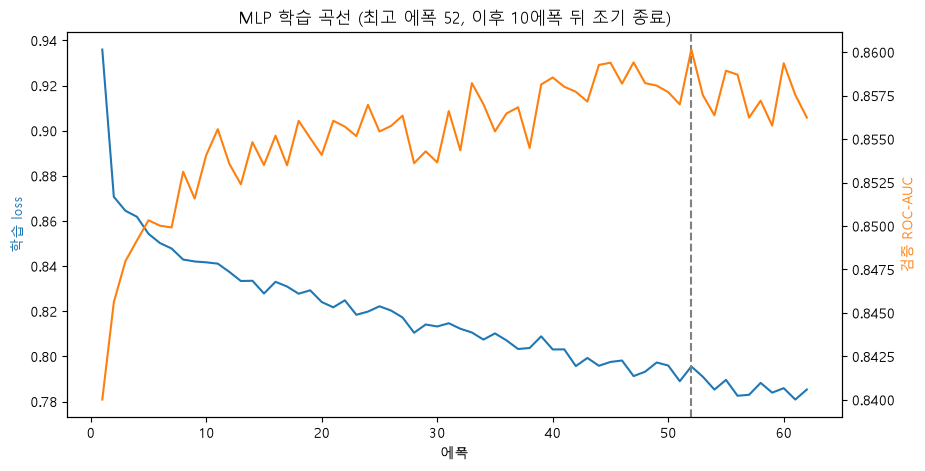

In [41]:
import matplotlib.pyplot as plt

hist = pd.DataFrame(history, columns=["epoch", "loss", "val_auc"])
best_epoch = hist.loc[hist["val_auc"].idxmax(), "epoch"]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(hist["epoch"], hist["loss"], color="tab:blue", label="학습 loss")
ax1.set_xlabel("에폭")
ax1.set_ylabel("학습 loss", color="tab:blue")

ax2 = ax1.twinx()
ax2.plot(hist["epoch"], hist["val_auc"], color="tab:orange", label="검증 ROC-AUC")
ax2.set_ylabel("검증 ROC-AUC", color="tab:orange")

ax1.axvline(best_epoch, color="gray", linestyle="--")
ax1.set_title(f"MLP 학습 곡선 (최고 에폭 {best_epoch}, 이후 10에폭 뒤 조기 종료)")
plt.show()